In [1]:
import scanpy as sc
import pandas as pd

In [2]:
adata = sc.read("../results/adata/08-preprocess.h5ad")

In [3]:
sc.tl.leiden(adata, key_added="leiden_0.15", resolution=0.15, flavor="igraph")

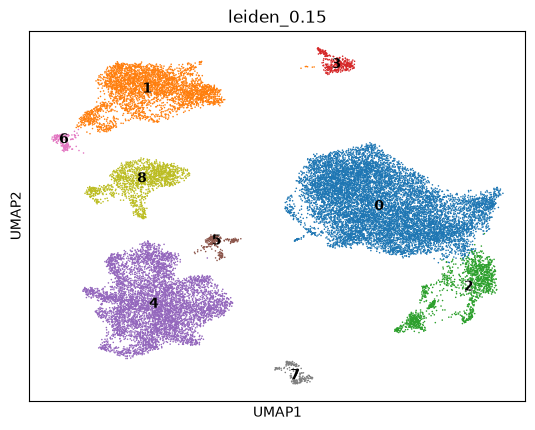

In [4]:
sc.pl.umap(adata, color="leiden_0.15", legend_loc="on data")

In [5]:
sc.tl.leiden(adata, key_added="leiden_0.5", resolution=0.5, flavor="igraph")

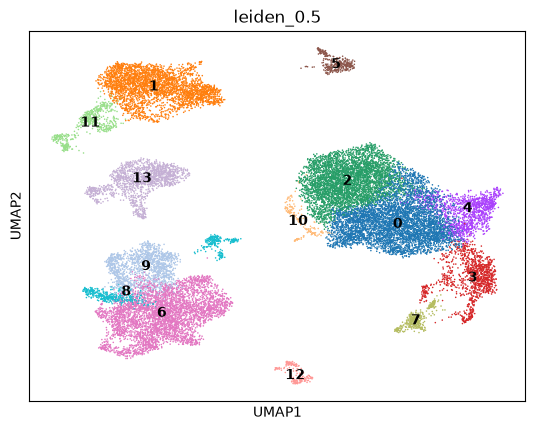

In [6]:
sc.pl.umap(adata, color="leiden_0.5", legend_loc="on data")

In [7]:
marker_genes = {
    "MuSCs & progenitors": ["Pax7", "Myod1"],
    "Mature skeletal muscle": ["Myod1", "Myh1", "Acta1"],
    "FAPS": ["Pdgfra"],
    "Tenocytes": ["Scx"],
    "Endothelial": ["Cdh5"],
    "SMCs & Mesencymal progenitors": ["Cdh5", "Myl9"],
    "Schwann cells": ["Mpz"],
    "Neural/Glial cells": ["Ptn"],
    "Monocytes/Macrophages/Platelets": ["Ptprc", "Ccl6", "Cd74", "C1qa"],
    "Pro-inflammatory macrophages": ["Ptprc", "Ccl6"],
    "Resident macrophages/APCs": ["Ptprc", "Cd74"],
    "Anti-inflammatory macrophages": ["Ptprc", "Cd74", "C1qa"],
    "B, T, & NK cells": ["Ptprc", "Nkg7"]
}
    

MuSCs & progenitors:


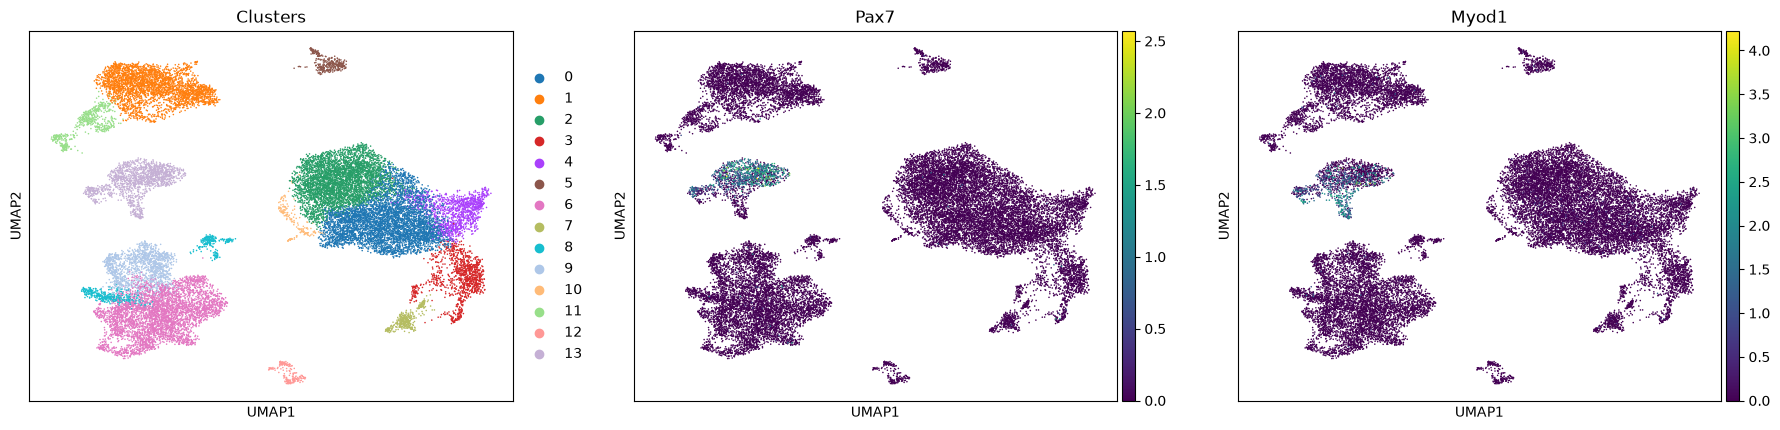

Mature skeletal muscle:


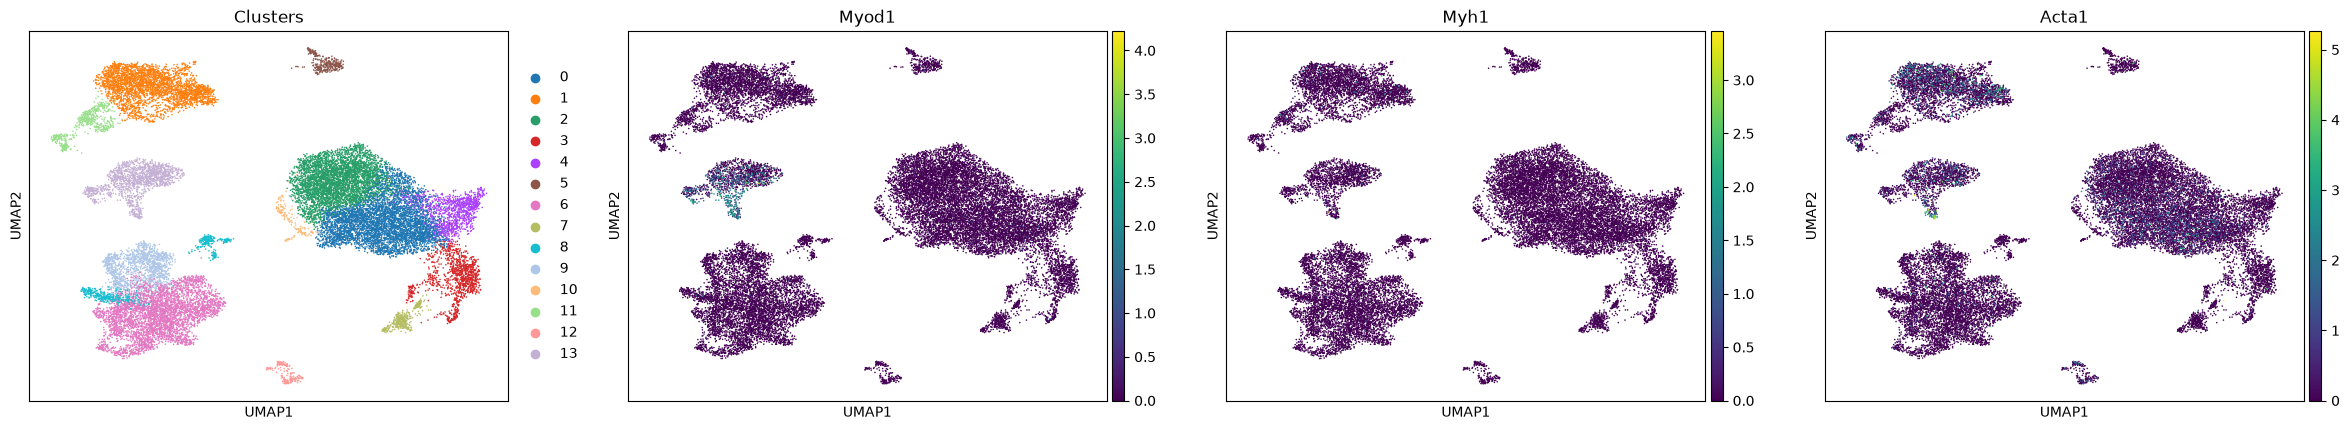

FAPS:


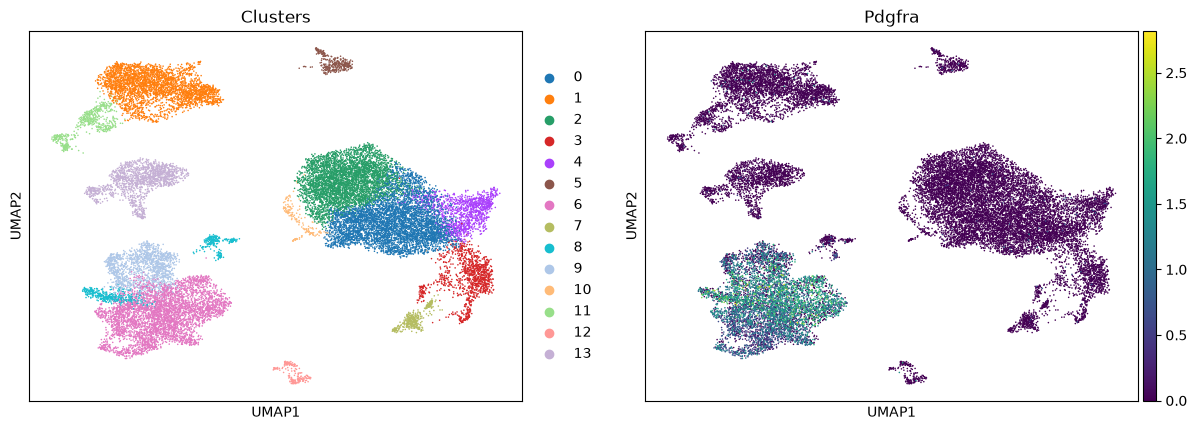

Tenocytes:


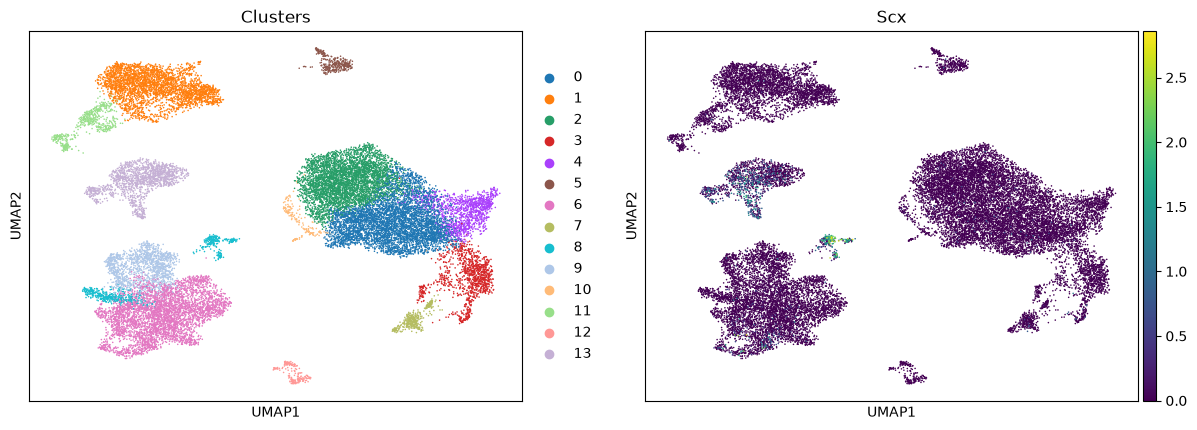

Endothelial:


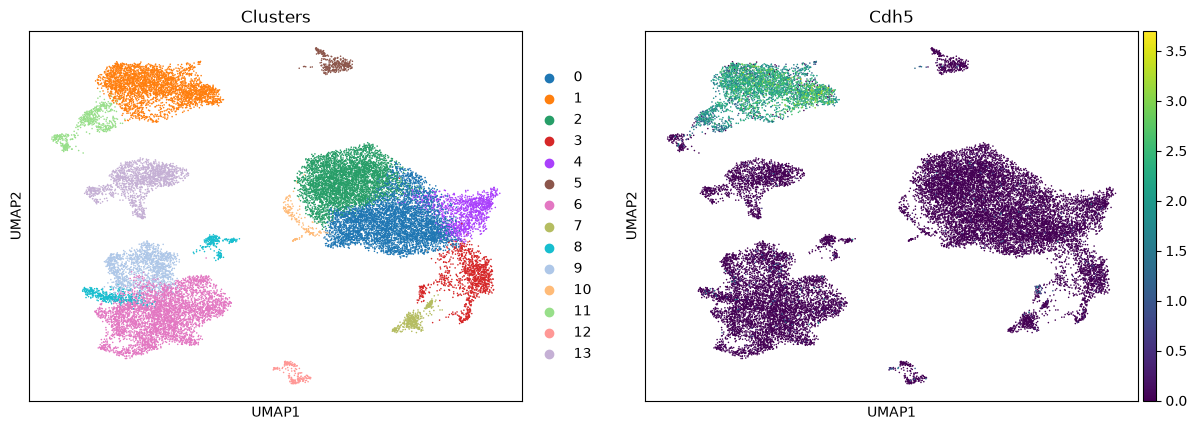

SMCs & Mesencymal progenitors:


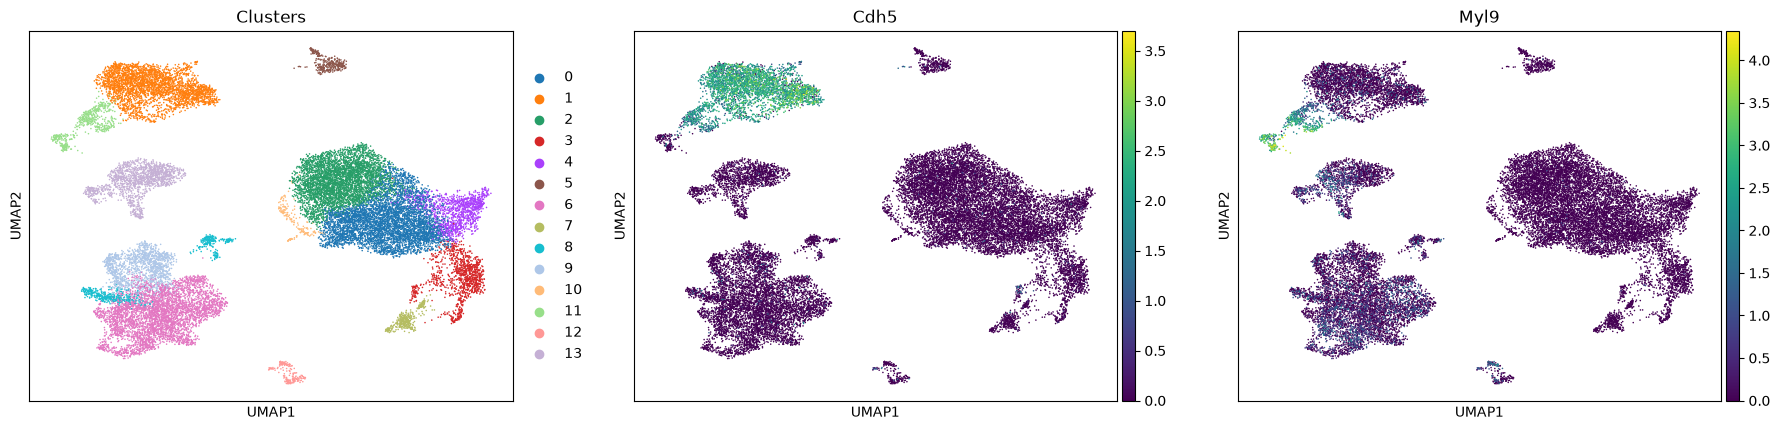

Schwann cells:


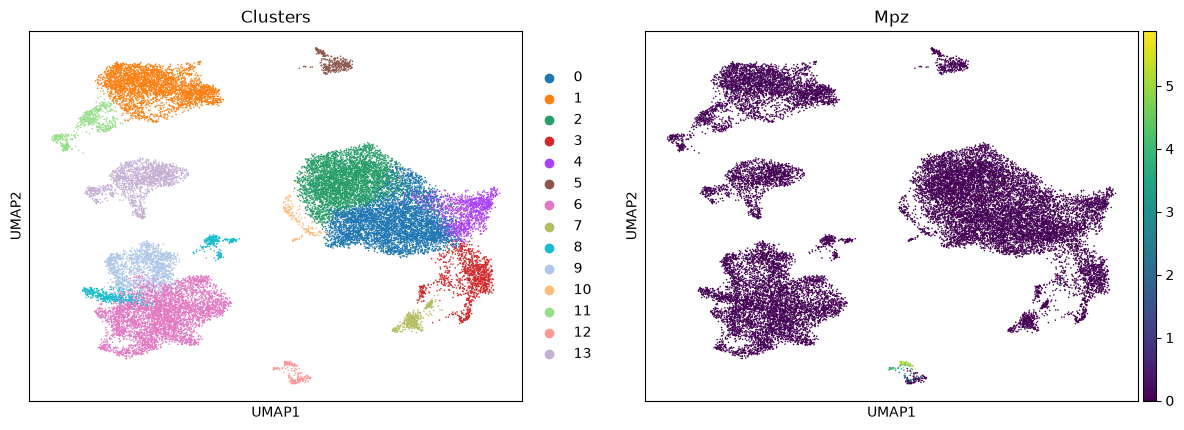

Neural/Glial cells:


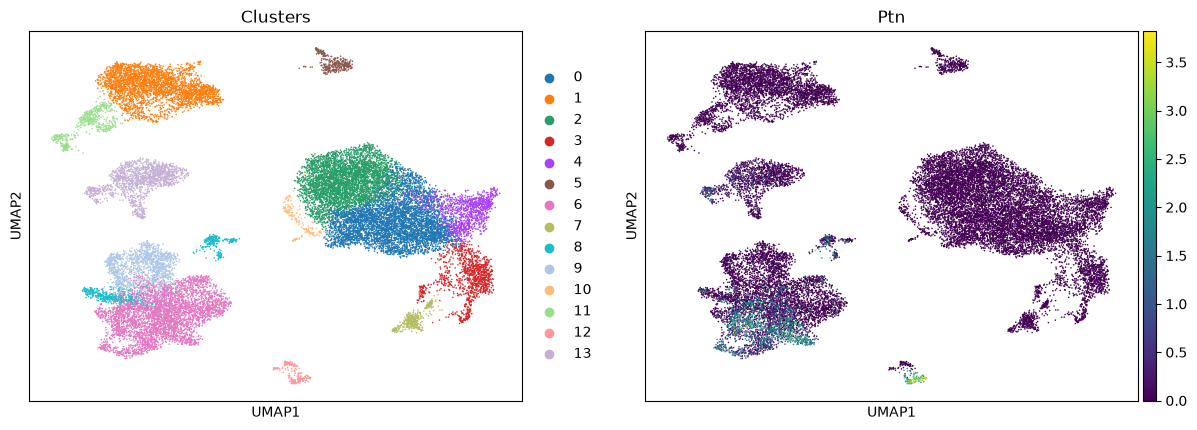

Monocytes/Macrophages/Platelets:


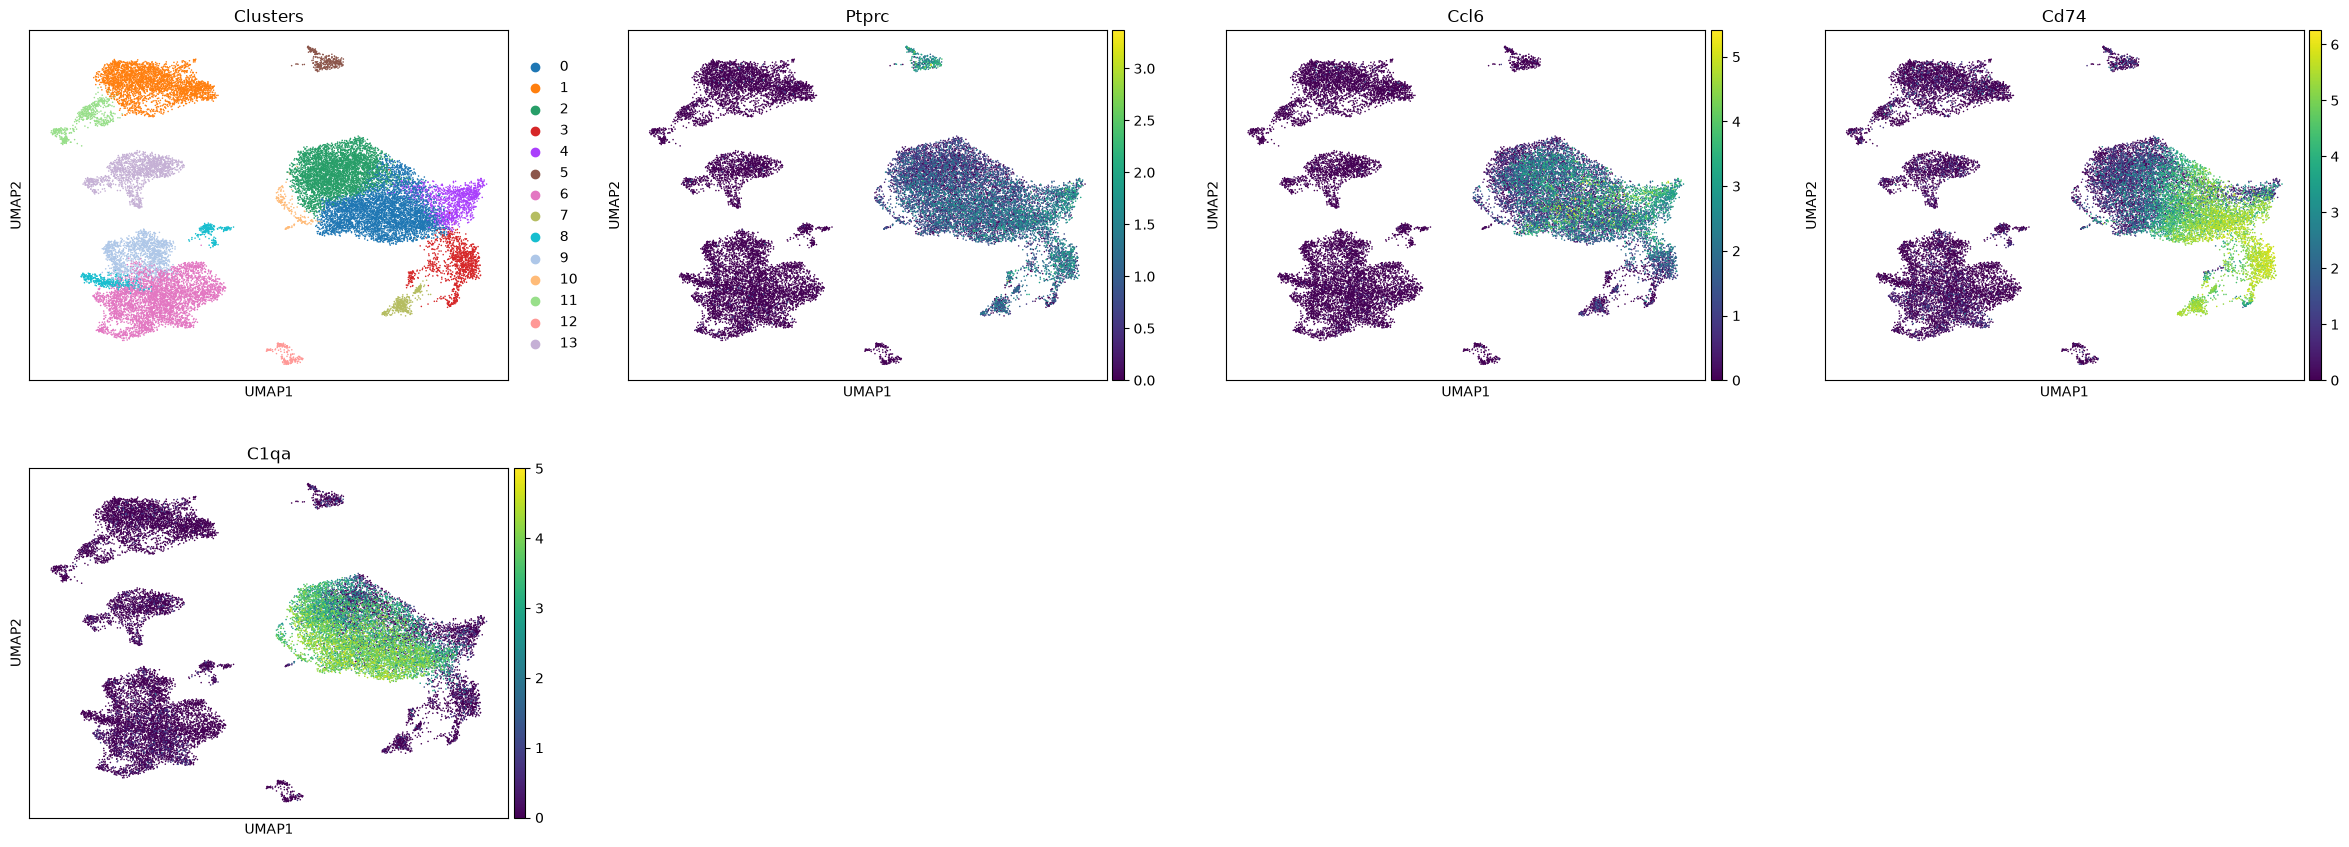

Pro-inflammatory macrophages:


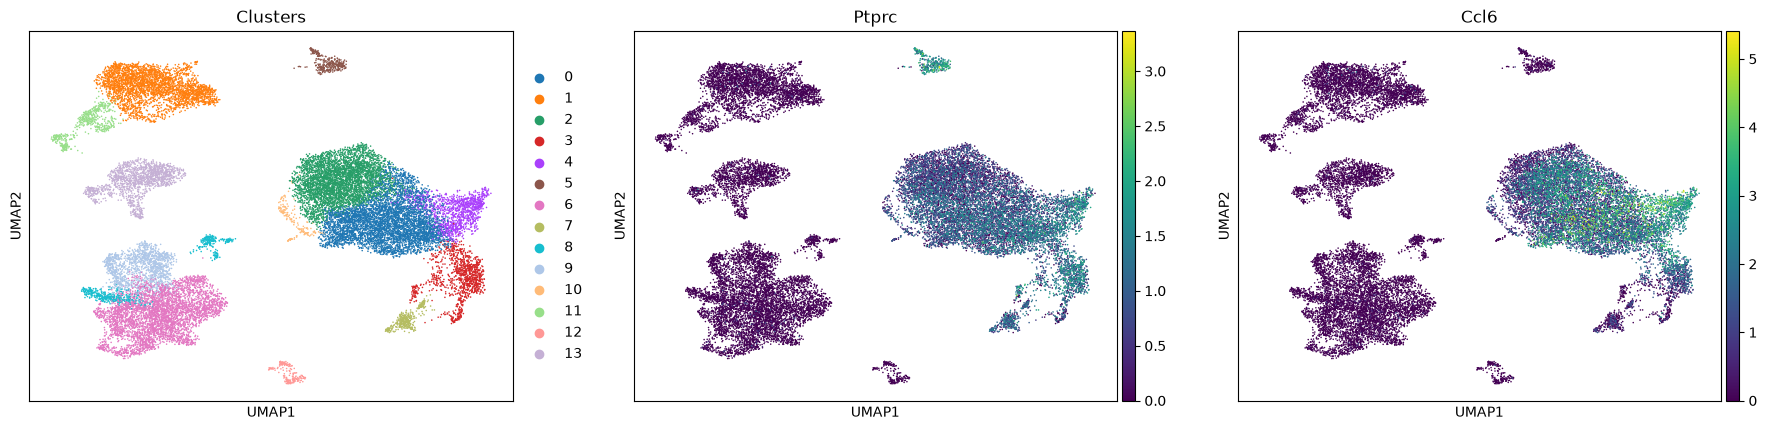

Resident macrophages/APCs:


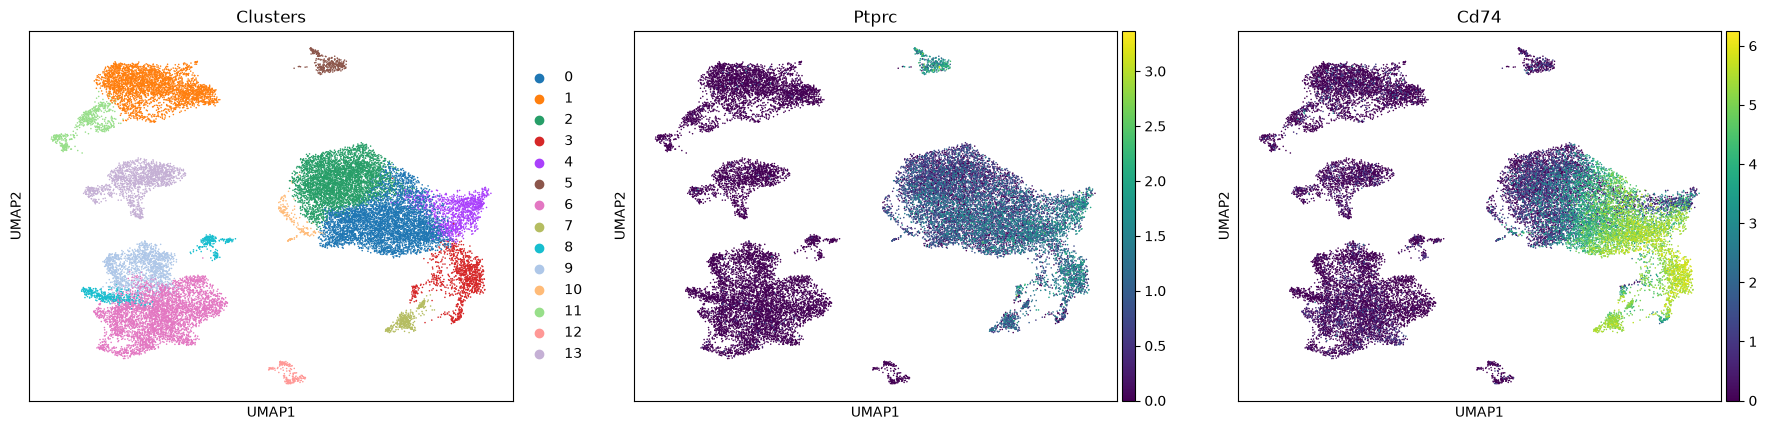

Anti-inflammatory macrophages:


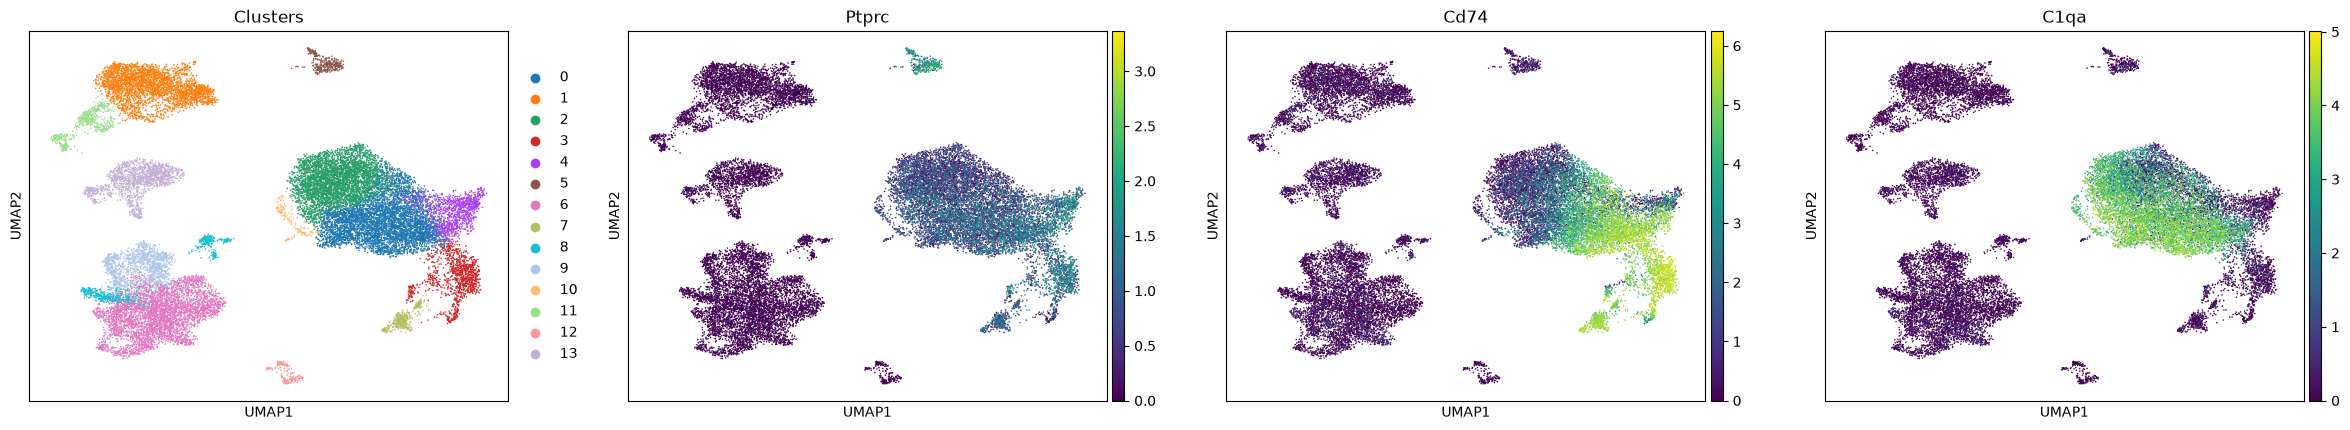

B, T, & NK cells:


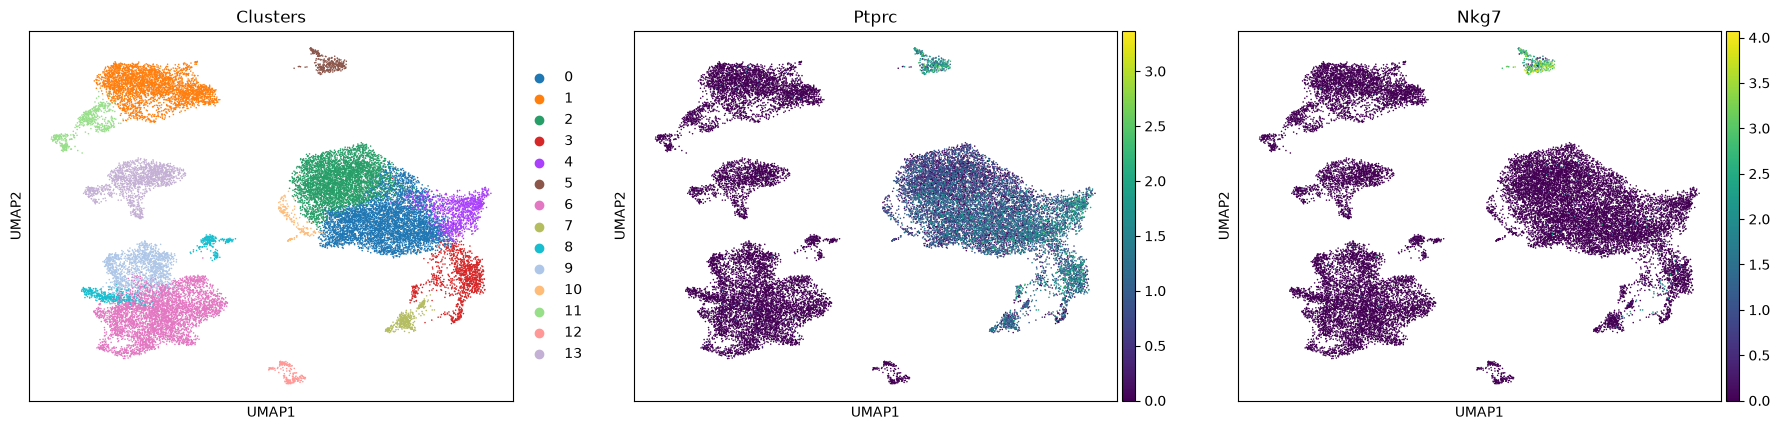

In [8]:
for cell_type, genes in marker_genes.items():
    print(f"{cell_type}:")
    sc.pl.umap(adata, color=["leiden_0.5"] + genes, title=["Clusters"] + genes)

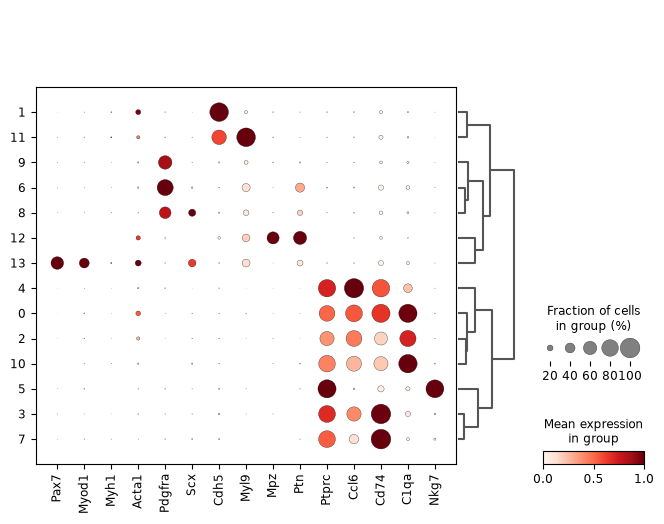

In [9]:
dotplot_genes = ['Pax7', 'Myod1', 'Myh1', 'Acta1','Pdgfra', 'Scx', 'Cdh5', 'Myl9', 
                 'Mpz', 'Ptn', 'Ptprc', 'Ccl6', 'Cd74', 'C1qa', 'Nkg7']
sc.pl.dotplot(adata, var_names=dotplot_genes, groupby="leiden_0.5", standard_scale="var", dendrogram=True)

In [ ]:
sc.tl.rank_genes_groups(adata, "leiden_0.5", method="wilcoxon")
sc.pl.rank_genes_groups(adata)

In [ ]:
sc.pl.rank_genes_groups_dotplot(adata, groupby="leiden_0.5", n_genes=5)

In [ ]:
sc.tl.filter_rank_genes_groups(adata, min_in_group_fraction=0.2,
                               max_out_group_fraction=0.2)

In [ ]:
sc.pl.rank_genes_groups_dotplot(adata, groupby="leiden_0.5", n_genes=5, key="rank_genes_groups_filtered")

In [ ]:
for group in adata.uns["rank_genes_groups_filtered"]["names"].dtype.names:
    genes = adata.uns["rank_genes_groups_filtered"]["names"][group]
    top10 = genes[~pd.isna(genes)][:10]

    print(f"Group {group}:")
    print(", ".join(top10))

In [ ]:
adata.obs["cell_type"] = None
adata.obs.loc[adata.obs["leiden_0.15"] == "8", "cell_type"] = "muscle"
adata.obs.loc[adata.obs["leiden_0.15"].isin(["0", "2"]), "cell_type"] = "macrophages"

In [ ]:
del adata.uns["rank_genes_groups_filtered"]
adata.write("../results/adata/09-annotation.h5ad")